# Kapitel 10 - Lösungen

In [1]:
# Aufgabe 1 - Schnitt zweier Ellipsen
import scipy as sp
def g1(p): # 1. Ellipsengleichung
    [x,y]=p
    return x**2+2*y**2+x-10
def g2(p): # 2. Ellipsengleichung
    [x,y]=p
    return 2*x**2+y**2-y-5
def LöseSys(gs:list,x0:list)->list:
    def f(x):
        return sum([g(x)**2 for g in gs])
    res = sp.optimize.minimize(f,x0)
    if res.success:
        return list(res.x)
    return []
# Je nach Startwert gibt es verschiedene Lösungen
for x0 in range(-2,3):
    for y0 in range(-2,3):
        lsg=LöseSys([g1,g2],[x0,y0])
        print("Start in",[x0,y0],"gibt",lsg,"Defekte",round(g1(lsg),3),round(g2(lsg),3))


Start in [-2, -2] gibt [np.float64(0.22437573777946515), np.float64(-2.092022420761891)] Defekte -0.972 1.569
Start in [-2, -1] gibt [np.float64(0.2243760032162391), np.float64(-2.092022330023434)] Defekte -0.972 1.569
Start in [-2, 0] gibt [np.float64(-1.0635541196729887), np.float64(2.228497998051755)] Defekte -0.0 0.0
Start in [-2, 1] gibt [np.float64(-1.0635540734933597), np.float64(2.2284980519780366)] Defekte 0.0 0.0
Start in [-2, 2] gibt [np.float64(-1.0635540969580375), np.float64(2.2284980192728674)] Defekte 0.0 0.0
Start in [-1, -2] gibt [np.float64(0.22437599122268723), np.float64(-2.0920223390089463)] Defekte -0.972 1.569
Start in [-1, -1] gibt [np.float64(0.22437595967317772), np.float64(-2.0920223660560167)] Defekte -0.972 1.569
Start in [-1, 0] gibt [np.float64(0.224376064304001), np.float64(-2.092022319964347)] Defekte -0.972 1.569
Start in [-1, 1] gibt [np.float64(-1.0635541212519304), np.float64(2.2284979996700356)] Defekte -0.0 0.0
Start in [-1, 2] gibt [np.float64(-

Erfolg: True - Optimization terminated successfully
yi= : [np.float64(-1.4489742603669897), np.float64(-2.236778094121203), np.float64(-2.792310052817777), np.float64(-3.2112523187795396), np.float64(-3.5330978761521226), np.float64(-3.7782375059864024), np.float64(-3.9585303093713153), np.float64(-4.08116405485203), np.float64(-4.150406057821599), np.float64(-4.168496563436188), np.float64(-4.136013387799287), np.float64(-4.0519095455139285), np.float64(-3.9134517996011415), np.float64(-3.7156416218224098), np.float64(-3.450208072056907), np.float64(-3.103399530430501), np.float64(-2.6509814234794087), np.float64(-2.0438159562589395), np.float64(-1.1489425249579428)] O minimal= -61.07361095562563


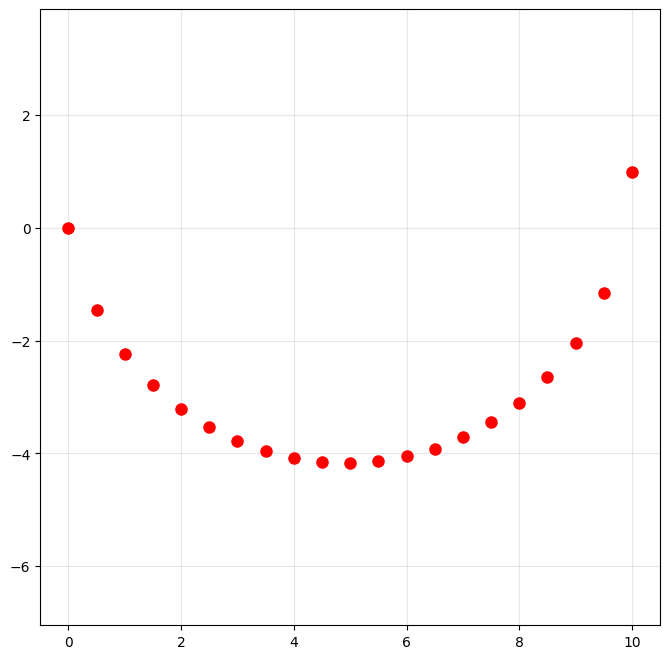

In [2]:
# Aufgabe 2 - Hängende Kette
A=[0,0]; B=[10,1] # Anfangs- und Endpunkt
L=15 # Länge der Kette
n=20 # Zahl der Zwischenstellen
dx=(B[0]-A[0])/n
xi=[A[0]+i*dx for i in range(0,n+1)]
y0=[i*(B[1]-A[1]) for i in range(1,n)] # Startwert für y, innere Knoten
import math
def LängenBedingung(yi)->float: 
    y=[A[1]]+list(yi)+[B[1]]
    return L-sum([math.sqrt(dx**2+(y[i+1]-y[i])**2) for i in range(len(y)-1)]) 
def Energie(yi)->float:
    y=[A[1]]+list(yi)+[B[1]]
    return sum([(y[i+1]+y[i])/2 for i in range(len(y)-1)])

import scipy as sp
res = sp.optimize.minimize(Energie,y0,
    constraints=[{'type': 'eq', 'fun': LängenBedingung}],
                          options={'maxiter': 10000}  )
print("Erfolg:", res.success, "-", res.message)
print("yi= :", list(res.x),"O minimal=",res.fun)
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
plt.plot(xi, [A[1]]+list(res.x)+[B[1]], 'ro', markersize=8)
plt.grid(True, alpha=0.3); plt.axis('equal'); plt.show()

In [3]:
# Aufgabe 3
S=math.pi
def integral(f,a,b,n=500):
    dx=(b-a)/n
    return sum([f(a+i*dx)*dx for i in range(n)])
def abstand(f,g,a,b):
    return integral(lambda x: (f(x)-g(x))**2, a,b)
def polyWertFun(p:list):
    def wert(x):
        return sum([p[k]*x**k for k in range(len(p))])
    return wert
def T3(x): # Taylor Grad 3
    return x+x**3/6    
def Zielfunktion(p)->float:
    return abstand(math.sin,polyWertFun(p),0,S)
p0=[0,1,0,1] # Startwerte für Polynom Grad 3
res = sp.optimize.minimize(Zielfunktion,p0)
print("Erfolg:", res.success, "-", res.message)
print("coeff :", list(res.x)," minimal=",res.fun)
print("Abstand zu Taylor ", abstand(math.sin,T3,0,S))  

Erfolg: False - Desired error not necessarily achieved due to precision loss.
coeff : [np.float64(-0.04946380159970397), np.float64(1.3093555600108429), np.float64(-0.41555276628570115), np.float64(-0.0004560427182169928)]  minimal= 0.0009361816504208451
Abstand zu Taylor  33.74086850627268
